# IS 4487 Assignment 9: Customer Segmentation with Clustering

In this assignment, you will:
- Apply unsupervised learning to explore patterns in hotel booking behavior
- Use K-Means and Gaussian Mixture Models (GMM) for customer segmentation
- Evaluate model quality with metrics like Silhouette Score and Davies-Bouldin Index
- Connect clustering to actionable business insights

## Why This Matters

Businesses like hotels and travel platforms (e.g., Airbnb or Expedia) rely on customer segmentation to tailor promotions, pricing strategies, and service levels. Unlike supervised models, clustering helps uncover patterns when no labels exist—an ideal tool when entering new markets or analyzing unstructured customer behavior.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.

## 1. Setup and Load Data

### Business framing:  

### Do the following:
Before we can cluster or segment anything, we need clean, accessible data in a usable format.

- Import the necessary Python libraries
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows

### In Your Response:
1. What stands out in the initial preview? Any columns or rows that seem unusual?

In [8]:
import pandas as pd

# URL for the hotels.csv dataset
url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv"

# Load the dataset into a pandas DataFrame
hotel_data = pd.read_csv(url)

# Display the first few rows of the DataFrame
print("First 5 rows of the dataset:")
print(hotel_data.head())

First 5 rows of the dataset:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2

### ✍️ Your Response: 🔧
1. A number of things stand out in this data including the missing data from the agent and company. In addition to this, the Average Daily rate is at 0 for the first two resorts which is not normal for a hotel. Stays in weekend nights and week nights are also at 0 on the first two rows, so this indicates something may be missing. The lead time for the first two hotels is also stretched out very far and may have some skewed data.

## 2. Select and Prepare Features

### Business framing:  

A hotel might want to group guests based on how long they stay, how far in advance they book, or how likely they are to make special requests. You need to pick variables that represent meaningful guest behavior.

### Do the following:
- Choose 3–5 numeric features related to customer behavior
- Drop missing values if needed
- Standardize using `StandardScaler`

### In Your Response:
1. What features did you select and why?
2. What kinds of patterns or segments do you expect to find?


In [9]:
from sklearn.preprocessing import StandardScaler

# 1. Choose 3-5 numeric features related to customer behavior
# I'll select 'lead_time', 'total_of_special_requests', 'adr', 'stays_in_weekend_nights', and 'stays_in_week_nights'
selected_features = [
    'lead_time',
    'total_of_special_requests',
    'adr',
    'stays_in_weekend_nights',
    'stays_in_week_nights'
]

# Create a new DataFrame with the selected features
X = hotel_data[selected_features].copy()

# 2. Drop missing values if needed
# Check for missing values in the selected features
missing_values_count = X.isnull().sum()
print("Missing values before dropping:\n", missing_values_count[missing_values_count > 0])

# Drop rows with any missing values in the selected features
X.dropna(inplace=True)

print("\nShape of data after dropping missing values:", X.shape)

# 3. Standardize using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better readability and to keep feature names
X_scaled_df = pd.DataFrame(X_scaled, columns=selected_features)

print("\nFirst 5 rows of the standardized data:")
print(X_scaled_df.head())

Missing values before dropping:
 Series([], dtype: int64)

Shape of data after dropping missing values: (119390, 5)

First 5 rows of the standardized data:
   lead_time  total_of_special_requests       adr  stays_in_weekend_nights  \
0   2.227051                  -0.720694 -2.015038                 -0.92889   
1   5.923385                  -0.720694 -2.015038                 -0.92889   
2  -0.907814                  -0.720694 -0.530935                 -0.92889   
3  -0.851667                  -0.720694 -0.530935                 -0.92889   
4  -0.842309                   0.540666 -0.075810                 -0.92889   

   stays_in_week_nights  
0             -1.310240  
1             -1.310240  
2             -0.786207  
3             -0.786207  
4             -0.262174  


### ✍️ Your Response: 🔧
1. I selected 'lead_time', 'total_of_special_requests', 'adr', 'stays_in_weekend_nights', and 'stays_in_week_nights'. Lead time helps identify booking behavior patterns, total of special requests indicates customer engagement or service expectations, adr is a key revenue variable, stays in weekend nights helps identify travel purpose patterns, and stays in week nights helps capture business vs. leisure travel behavior.

2. With these features several patterns and customer segments may appear including last minute budget travelers (low lead time, low adr, few special requests, short stays), luxury or high value guests (high adr, more total of special requests, possibly longer stays), early planners (very high lead time, moderate adr, moderate length of stay), weekend leisure travelers (high stays in weekend nights, moderate adr, possible short lead time), and business travelers (more stays on week nights, low weekend stays, moderate adr, short lead time).


## 3. Apply K-Means Clustering

### Business framing:  

Let’s say you’re working with the hotel’s marketing manager. She wants to group guests into a few clear types to target email campaigns. K-Means is a fast, simple way to try this.

### Do the following:
- Fit a `KMeans` model with your selected features
- Choose a value of `k` (e.g. 3, 4, or 5)
- Predict clusters and assign to each guest
- Visualize using a scatterplot of 2 features

Much of this assignment has already been covered in the lab. Please be sure to complete the lab before the assignment.

### In Your Response:
1. What `k` value did you choose, and how did you decide?
2. What types of customers seem to show up in the clusters?



K-Means clustering with k=4 completed. Clusters assigned.
Cluster distribution:
 cluster
2    54220
3    27955
0    21456
1    15759
Name: count, dtype: int64


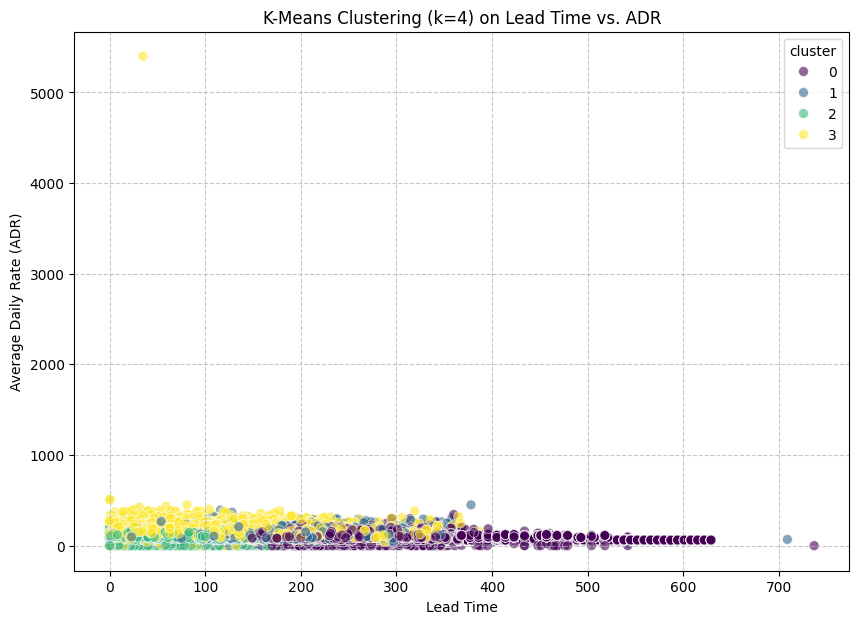

In [10]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a value of k
k = 4  # Let's start with 4 clusters

# Fit a KMeans model
kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is added to suppress warning
kmeans_model.fit(X_scaled)

# Predict clusters and assign to each guest
cluster_labels = kmeans_model.labels_

# Add cluster labels to the original (non-scaled) DataFrame for easier interpretation
X_clustered = X.copy()
X_clustered['cluster'] = cluster_labels

print(f"K-Means clustering with k={k} completed. Clusters assigned.")
print("Cluster distribution:\n", X_clustered['cluster'].value_counts())

# Visualize using a scatterplot of 2 features
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='lead_time',
    y='adr',
    hue='cluster',
    data=X_clustered,
    palette='viridis',
    s=50, alpha=0.6
)
plt.title(f'K-Means Clustering (k={k}) on Lead Time vs. ADR')
plt.xlabel('Lead Time')
plt.ylabel('Average Daily Rate (ADR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### ✍️ Your Response: 🔧
1. The value chosen was k=4 because it balances meaningful segmentation and interpretability that provides clear group separation while still being easy to interpret for business decisions.

2. Cluster 0 with the long lead time planners showing a high lead time with a moderate adr. Cluster 1 with the high spenders and premium guests with high adr values and moderate lead times. Cluster 2 with budget or short notice travelers with the lower adr and lower to moderate lead times.


## 4. Apply Gaussian Mixture Model (GMM)

### Business framing:  

Not all guests fit neatly into one cluster. GMM lets us capture uncertainty — useful if customers behave similarly across groups.

### Do the following:
- Fit a GMM with the same number of clusters you chose in Part 3
- Predict soft clusters (remember that soft clustering deals with probabilities, not labels)
- Visualize the GMM model so that you may compare it to the KMeans scatterplot

### In Your Response:
1. How did the GMM results compare to KMeans?
2. What business questions might GMM help answer better?


GMM clustering with k=4 completed. Clusters assigned.
Cluster distribution (based on highest probability):
 cluster
0    69628
2    32902
3    12824
1     4036
Name: count, dtype: int64


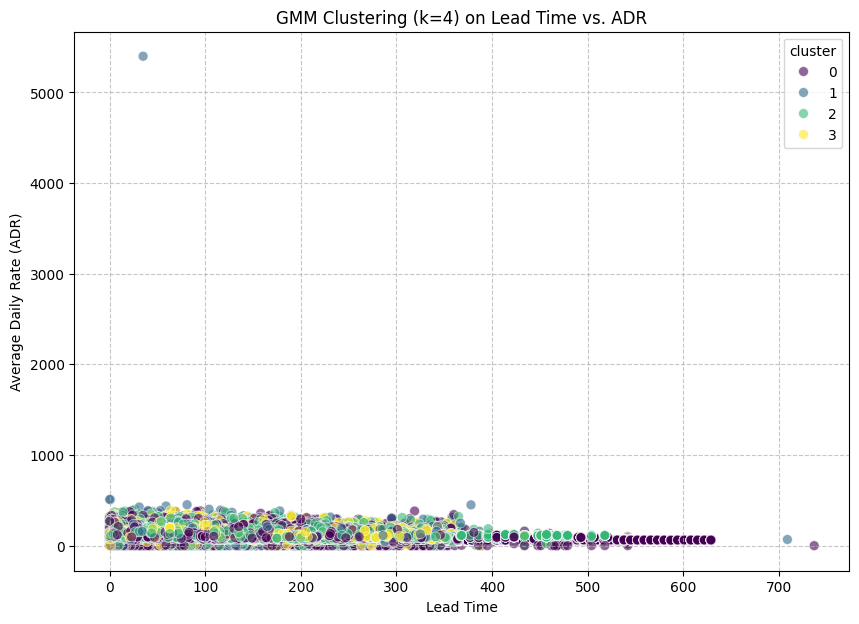

In [11]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

# Use the same number of clusters (k) as in KMeans
# k is already defined from the previous cell, so we can reuse it.
# k = 4

# Fit a Gaussian Mixture Model
gmm_model = GaussianMixture(n_components=k, random_state=42)
gmm_model.fit(X_scaled)

# Predict soft clusters (probabilities for each cluster)
cluster_probabilities = gmm_model.predict_proba(X_scaled)

# For visualization, we often need a 'hard' assignment, so we'll assign each point
# to the cluster with the highest probability. These are the effective labels.
gmm_labels = gmm_model.predict(X_scaled)

# Add GMM labels to a copy of the original (non-scaled) DataFrame
X_gmm_clustered = X.copy()
X_gmm_clustered['cluster'] = gmm_labels

print(f"GMM clustering with k={k} completed. Clusters assigned.")
print("Cluster distribution (based on highest probability):\n", X_gmm_clustered['cluster'].value_counts())

# Visualize using a scatterplot of 2 features
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='lead_time',
    y='adr',
    hue='cluster',
    data=X_gmm_clustered,
    palette='viridis',
    s=50, alpha=0.6
)
plt.title(f'GMM Clustering (k={k}) on Lead Time vs. ADR')
plt.xlabel('Lead Time')
plt.ylabel('Average Daily Rate (ADR)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### ✍️ Your Response: 🔧
1. The largest cluster in GMM is 69,628 and the largest with the KMeans is 54,220. The smallest cluster with GMM is 4,036 with the smallest of KMeans being 15,759. The KMeans clusters are circular and equally sized and the GMM is elliptical with different variances. The KMeans data belongs to one cluster only and the GMM allows for probabilities of each data point belonging to the clusters which spreads them out. For example, a guest might have a 70% chance of being a business traveler and a 30% chance of a leisure traveler.

2. GMM models probabilities and overlapping segments so it may be more useful for nuanced business insights. It can help determine which customers behave like multiple segments for possible hybrid marketing, which bookings are unusual or high-value outliers for premium guest profiles, what type of customer is this likely to be for targeted marketing, upgrade offers, and personalized pricing. These insights along with any overlapping customer behaviors that are available with GMM but not KMeans.


## 5. Evaluate Your Models

### Business framing:  

In business, models should be both useful and reliable. You’ll compare model quality using standard evaluation metrics.

### Do the following:
- Calculate the following **for each** of the models:
  - WCSS
  - Silhouette Score
  - Davies-Bouldin Index

  **NOTE:** This step may take up to 5 minutes.  It is a lot of computation time.  Please be patient.  Or you can limit the scores to using a random sample of 10K rows.

**Remember**:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### In Your Response:
1. Which model performed better on the metrics?
2. Would you recommend KMeans or GMM for a business analyst? Why?


In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# --- K-Means Model Evaluation ---
print("--- K-Means Model Evaluation ---")
# WCSS (Inertia) for KMeans
kmeans_wcss = kmeans_model.inertia_
print(f"KMeans WCSS (Inertia): {kmeans_wcss:.2f}")

# Silhouette Score for KMeans
# Use a sample if computation is too long
# For this dataset, it might be fine, but for larger, consider sampling.
# Example: if len(X_scaled) > 10000: indices = np.random.choice(len(X_scaled), 10000, replace=False)
# kmeans_silhouette = silhouette_score(X_scaled[indices], cluster_labels[indices])
kmeans_silhouette = silhouette_score(X_scaled, cluster_labels)
print(f"KMeans Silhouette Score: {kmeans_silhouette:.4f}")

# Davies-Bouldin Index for KMeans
kmeans_davies_bouldin = davies_bouldin_score(X_scaled, cluster_labels)
print(f"KMeans Davies-Bouldin Index: {kmeans_davies_bouldin:.4f}")

# --- GMM Model Evaluation ---
print("\n--- GMM Model Evaluation ---")
# WCSS is not directly applicable to GMM in the same way as KMeans (GMM optimizes log-likelihood).
# For comparison purposes, we'll calculate Silhouette and Davies-Bouldin for GMM's 'hard' assignments.

# Silhouette Score for GMM
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
print(f"GMM Silhouette Score: {gmm_silhouette:.4f}")

# Davies-Bouldin Index for GMM
gmm_davies_bouldin = davies_bouldin_score(X_scaled, gmm_labels)
print(f"GMM Davies-Bouldin Index: {gmm_davies_bouldin:.4f}")

--- K-Means Model Evaluation ---
KMeans WCSS (Inertia): 346243.97
KMeans Silhouette Score: 0.2329
KMeans Davies-Bouldin Index: 1.4098

--- GMM Model Evaluation ---
GMM Silhouette Score: 0.1239
GMM Davies-Bouldin Index: 2.6243


### ✍️ Your Response: 🔧
1. For both the silhouette score and the davies-bouldin, the KMeans performed better than the GMM for this data set. With the silhoette score the KMeans is higher and shows that the clusters are more clearly separated. With the davies-bouldin index the KMeans is lower because the clusters are more distinct and less overlapping.

2. For this dataset, I would recommend using the KMeans due to the more distinct and well separated clusters showing clearer segmentation. A business analyst usually needs to know easy, actionable segments such as early planners, budget travelers, premium guests, last-minute bookers, etc. Along with this, it will be easier for them to communicate the information to stakeholders.


## 6. Business Interpretation

### Business framing:  

What do these clusters mean in the real world? Could they represent solo travelers, families, or bargain shoppers?

### Do the following:
- Display the characteristics of each cluster (e.g. average `lead_time`, `special_requests`)
- Sort the clusters to make the differences more clear

### In Your Response:
1. What do the segments represent in terms of guest behavior?
2. How could the hotel tailor services or promotions to each group?


In [13]:
# Display the characteristics of each cluster
cluster_characteristics = X_clustered.groupby('cluster')[selected_features].mean()

# Sort the clusters to make differences clearer, for example, by 'lead_time'
cluster_characteristics_sorted = cluster_characteristics.sort_values(by='lead_time', ascending=True)

print("\nK-Means Cluster Characteristics (sorted by Lead Time):\n")
print(cluster_characteristics_sorted)

# Optionally, also show the size of each cluster
print("\nCluster Sizes:\n")
print(X_clustered['cluster'].value_counts().sort_index())



K-Means Cluster Characteristics (sorted by Lead Time):

          lead_time  total_of_special_requests         adr  \
cluster                                                      
2         45.504168                   0.226577   86.568845   
3         71.194670                   1.553604  140.829597   
1        134.566089                   0.526366  101.491484   
0        272.176221                   0.195936   89.837767   

         stays_in_weekend_nights  stays_in_week_nights  
cluster                                                 
2                       0.628329              1.755681  
3                       0.903631              2.313683  
1                       2.388476              5.801003  
0                       0.642105              2.200830  

Cluster Sizes:

cluster
0    21456
1    15759
2    54220
3    27955
Name: count, dtype: int64


### ✍️ Your Response: 🔧
1. Cluster 2 is the largest at 56,220 guests and the behavior is the short lead time budget travelers who book relatively close to arrival time and do not request many extras. Cluster 3 is the next largest with 27,955 guests and the behavior is the high-value leisure travelers who plan in advance and expect higher service levels. Cluster 1 is the smallest at 15,759 guests and the behavior is the long-stay vacation guests who are planning far in advance for family gatherings or long getaways. Cluster 0 is next with 21,456 guests and the behavior is early planners who are traveling for events, groups, organized activities.

2. For the budget travelers the hotel could offer an upgrade at check-in, promote any add-on features, send a last minute deal, promote a loyalty program, or offer a credit for using a service with the idea they will use it more. For the premium guests it is important to maximize satisfaction and retention by offering personalized services, concierge or experience packages, spa/dining packages, and priority service. For the long-stay guests the hotel could promote longer bookings and packages including family packages, activity bundles, and weekly pricing. For the early planners the hotel could give early bird discounts, flexible cancellation, early bird packages, and event promotions.


## 7. Final Reflection

### Business framing:  

Many teams ask for "segmentation" without knowing how it works. You now have hands-on experience with two clustering techniques and how to present the results.

### In Your Response:
1. What was most challenging about unsupervised learning?
2. When would you use clustering instead of supervised models?
3. How would you explain the value of clustering to a non-technical manager?
4. How does this relate to your customized learning outcome you created in canvas?


### ✍️ Your Response: 🔧
1. The most challenging aspect about unsupervised learning is that there is no labeled target variable to guide the model. There is no correct answer to compare predictions and this makes it more difficult to determine whether the clusters are meaningful. Another challenge is selecting an appropriate number of clusters and interpreting what each cluster means in terms of customer behavior.

2. I would use clustering instead of supervised models when there is no predefined target variable in order to find hidden patterns or natural groupings in the data. It can help me find customer segments, market analysis, anomolies in the data, and customer behavior.

3. Clustering helps organizations identify groups of customers with similar behaviors, so that they can make better business decisions. Clustering can tell if someone is a budget traveler, a premium customer, and make changes to their promotions and actions based on this information. This helps the business to use its resources wisely and better cater to its customers in the ways they appreciate and keeps them coming back.

4. This directly relates to my customized learning outcomes because I was able to create models based on data as a method to gain insight for better business decision making. I learned that through data I can learn about customer behaviors and use this insight to better inform management on how to utilize the business resources and keep our customers satisfied. This will be very important for my career moving forward.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [ ]:
!jupyter nbconvert --to html "assignment_09_clustering.ipynb"